# Data Initialization


In [29]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_csv('weekly_player_stats_offense.csv')

In [30]:
# initial values for labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
features_dropped = set([]) # remove from lists of kept features
target_labels = set(['fantasy_points_ppr'])


#print(target_labels)
#print("Categorical Features: ", categorical_features)
#print("Numerical Features: ", real_val_features)

In [31]:
for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        real_val_features.add(col)
    else :
        categorical_features.add(col)

#print(categorical_features)
#print(real_val_features)

In [32]:
# ensure target or potential target labels are dropped from model input df
for label in raw_df :
    label = str(label)
    if 'fantasy' in label :
        features_dropped.add(label)


for feature in features_dropped :
    if feature in real_val_features :
        real_val_features.remove(feature)
    elif feature in categorical_features :
        categorical_features.remove(feature)

#print(features_dropped)


In [33]:
# set fantasy points as targets 
# drop irrelevant / categorical features 
# condense samples to one per player - seasonal weekly average 
# make training-validation split 
# encode / normalize kept features 
# train / validate model 
# Remove features that have minimal impact on model performance 
# whatever the fuck else

# Categorical Stats
# position

# Numerical Stats
# week
# season
# passing_yards
# receiving_yards
# rushing_yards
# rush_touchdown
# pass_touchdown
# fumble_lost
# receptions
# interception

# Logically, we split the fantasy point stats between test and training and compare them against our model
# Target = fantasy_points_ppr

# plot each categorical feature and numerical feature
# find and fill holes or remove if missing too much data

# create test dataframe
# test_df = pd.concat(raw_df[catgeorical] , raw_df[real_value])

# ohe categorical features
# normalize numerical features

# train test split
	# split based on avverge fantasy points ppr? or some other metric ? 

# stick into a model - xgboost / random forest / linear regression

# graph model perofrmances, start selecting features based on importance, correlation, etc to combine or remove 

#plt.figure(dpi=500)
#sns.heatmap(position_filtered_df.isnull() , cbar=False , cmap='viridis')
#plt.ylabel('Samples')
#plt.xlabel('Features')

#plt.show()

In [34]:
# list of all features with missing 

temp = raw_df.drop(features_dropped, axis=1)
missing_values = set([])
for label in temp :
    label = str(label)
    if temp[label].isnull().any() :
        missing_values.add(label)

print(len(missing_values))
print(len(real_val_features) + len(categorical_features))

137
381


137
393


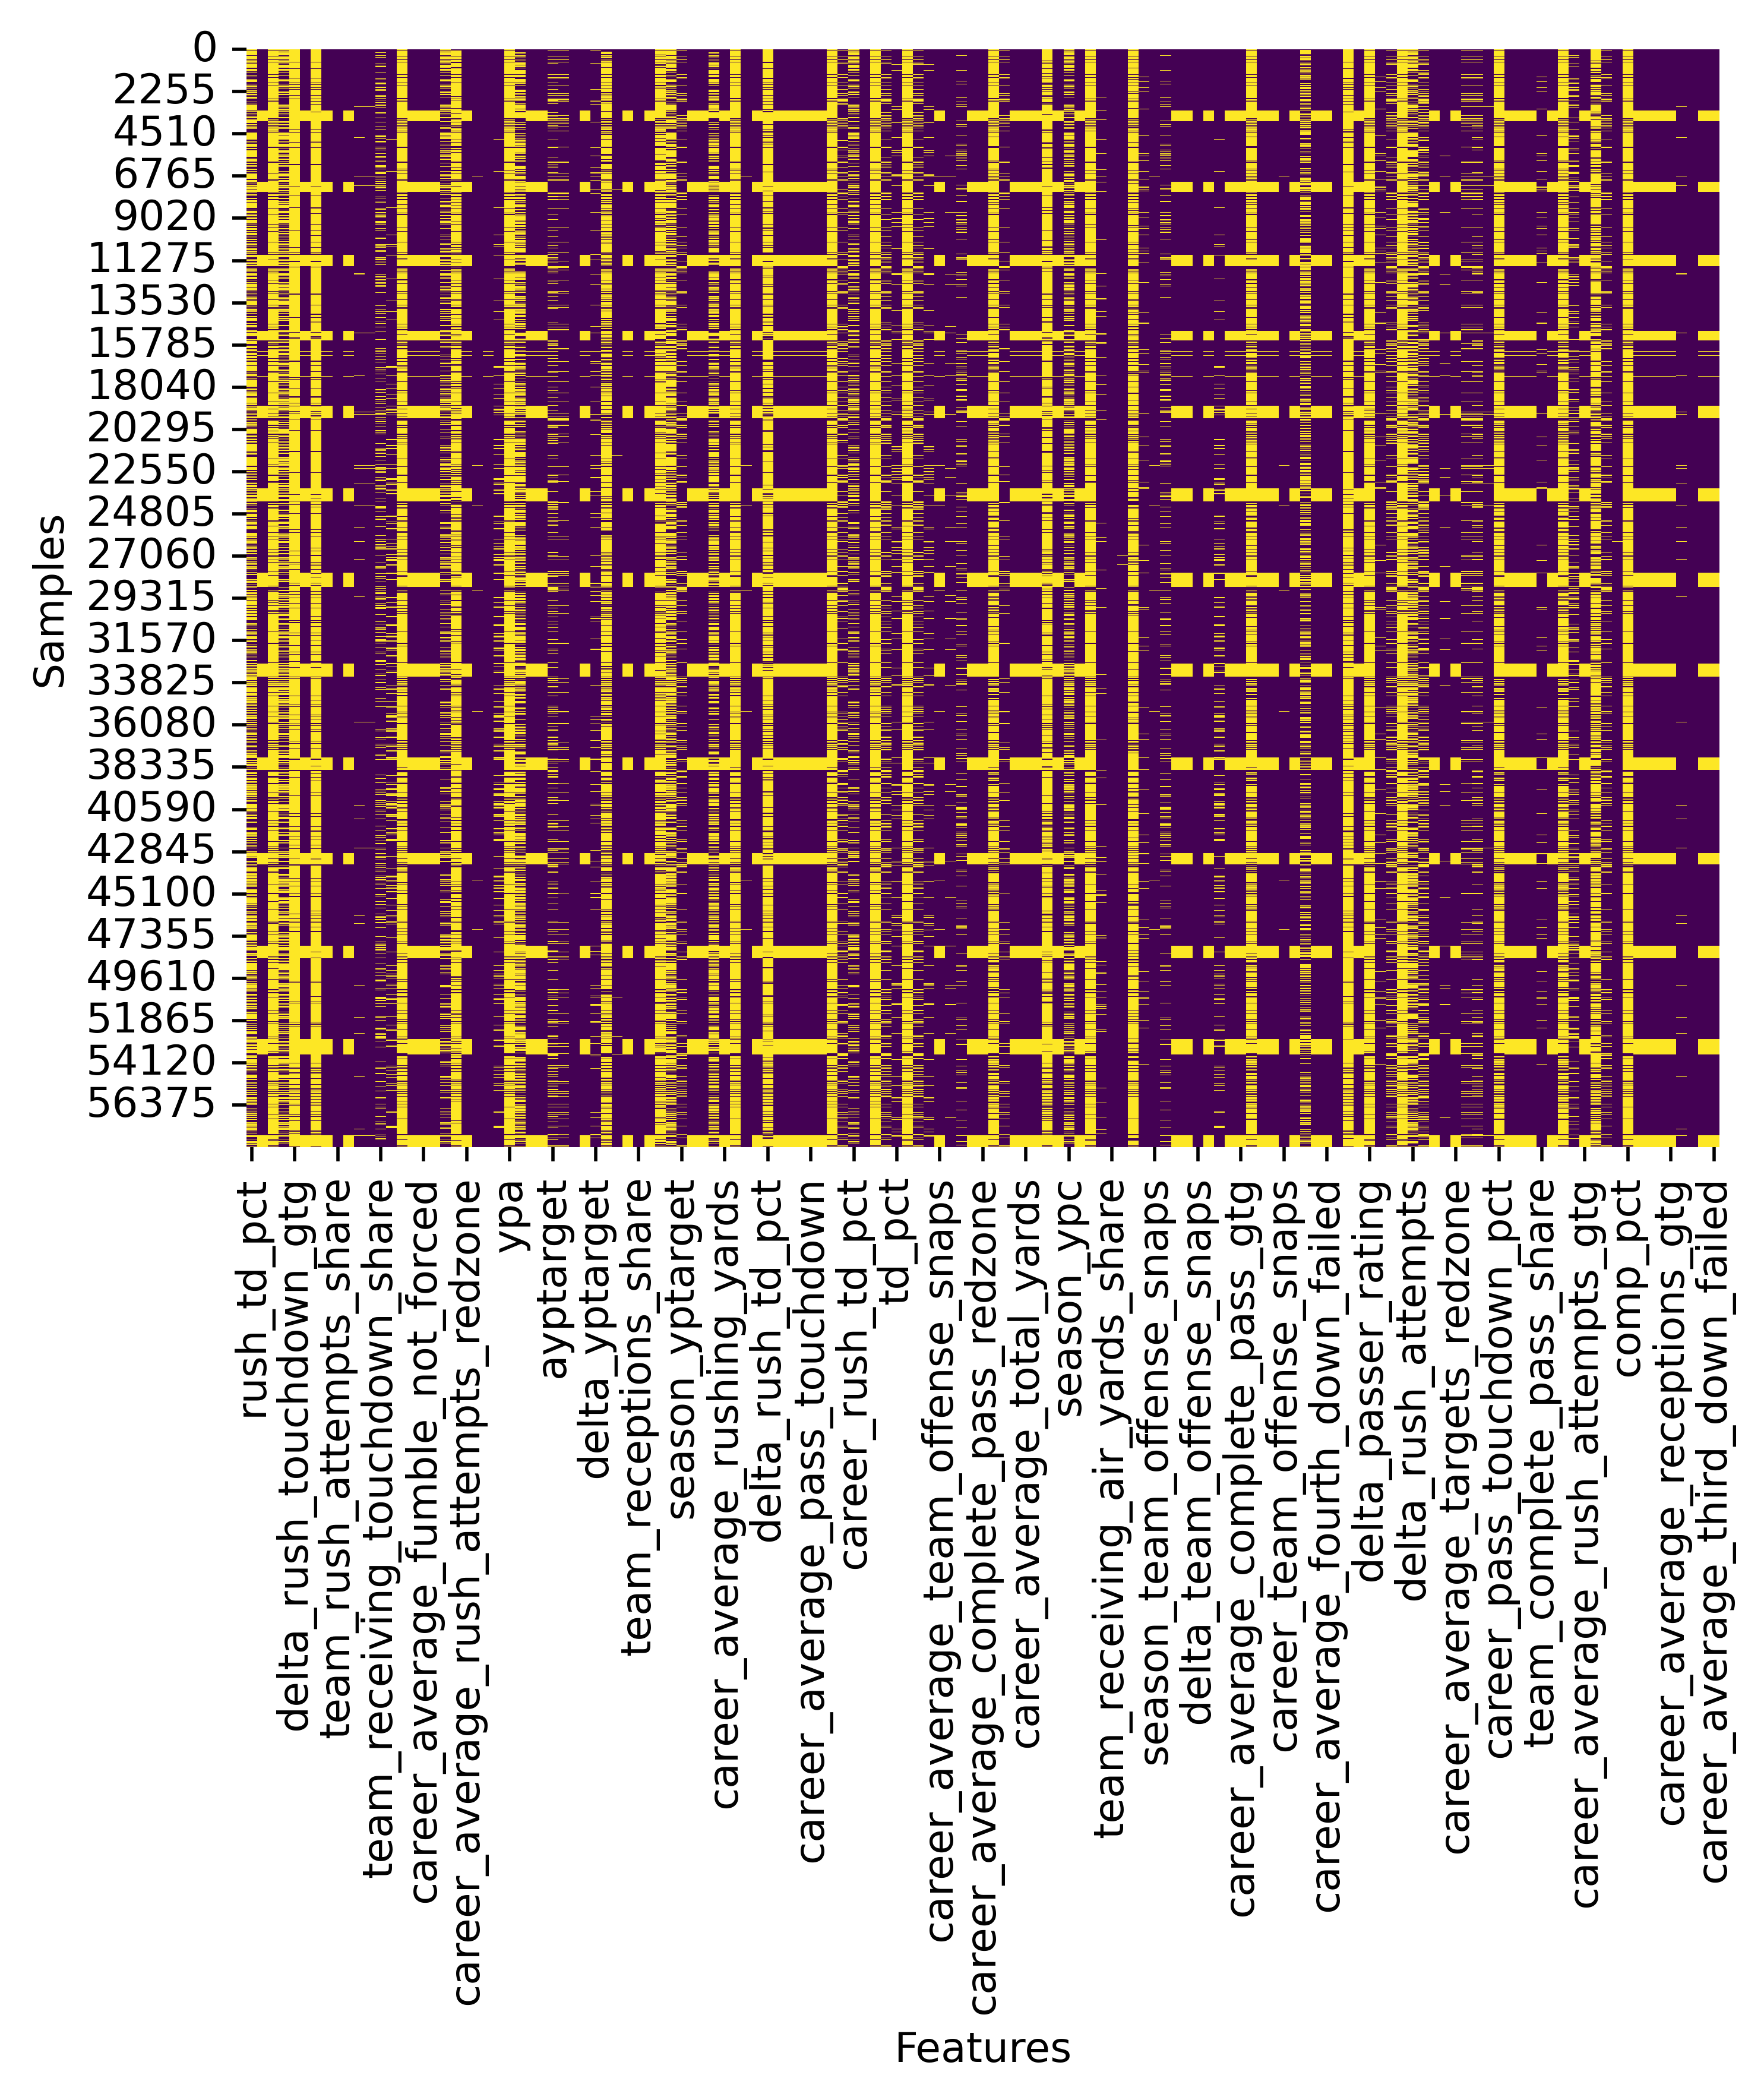

In [35]:
print(len(missing_values))
print(len(real_val_features) + len(categorical_features) + len(features_dropped))

plt.figure(dpi=500)
sns.heatmap(raw_df[list(missing_values)].isnull(), cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
plt.show()

In [36]:
# Creating a clean dataframe by dropping features with too many missing values
missing_threshold = 0.15  # Set threshold for missing values
missing_fraction = raw_df[list(missing_values)].isnull().mean()
potential_drop = missing_fraction[missing_fraction > missing_threshold].index
# features_dropped.update(potential_drop)
cleaned_df = raw_df.drop(columns=features_dropped)
print("Dropped features due to missing values: ", potential_drop.tolist())

# print("Cleaned DataFrame Features: ", cleaned_df.columns.tolist())

cleaned_categorical_features = [col for col in cleaned_df.columns if not pd.api.types.is_numeric_dtype(cleaned_df[col])]
cleaned_real_val_features = [col for col in cleaned_df.columns if pd.api.types.is_numeric_dtype(cleaned_df[col])]


Dropped features due to missing values:  ['rush_td_pct', 'delta_complete_pass', 'season_rush_td_pct', 'delta_rush_touchdown_gtg', 'delta_rush_touchdown_redzone', 'team_receiving_touchdown_share', 'season_ypa', 'career_ypc', 'delta_int_pct', 'ypa', 'delta_total_tds', 'ayptarget', 'pass_td_pct', 'int_pct', 'ypc', 'delta_td_pct', 'season_int_pct', 'delta_rush_td_pct', 'season_pass_touchdown_pct', 'delta_receiving_yards', 'career_rush_td_pct', 'season_comp_pct', 'adot', 'delta_pass_attempts', 'rec_td_pct', 'career_average_team_offense_snaps', 'career_ypa', 'delta_rush_attempts_gtg', 'season_ypc', 'delta_incomplete_pass', 'delta_pass_td_pct', 'career_int_pct', 'team_rush_touchdown_share', 'delta_rush_touchdown', 'delta_passer_rating', 'yptarget', 'delta_passing_yards', 'delta_rush_attempts', 'ypr', 'season_ypr', 'career_pass_touchdown_pct', 'career_comp_pct', 'team_pass_touchdown_share', 'delta_rush_attempts_redzone', 'comp_pct']


In [37]:
# Print the heatmap of the cleaned dataframe numerical features
# plt.figure(dpi=500)
# sns.heatmap(cleaned_df[cleaned_real_val_features].isnull() , cbar=False , cmap='viridis')
# plt.ylabel('Samples')
# plt.xlabel('Features')
# plt.show()

Dropped features for position QB due to missing values: 
adot
rec_td_pct
yptarget
ayptarget
ypr
delta_receiving_yards
delta_rush_touchdown
delta_rush_attempts_redzone
delta_rush_touchdown_redzone
delta_rush_attempts_gtg
delta_rush_touchdown_gtg
delta_int_pct
delta_yptarget
delta_rush_td_pct
team_pass_touchdown_share
team_receiving_touchdown_share
team_rush_touchdown_share
season_rec_td_pct
season_yptarget
season_ypr
career_rec_td_pct
career_yptarget
career_ypr
Position QB Filtered DataFrame Features:  ['season', 'week', 'offense_snaps', 'offense_pct', 'team_offense_snaps', 'player_id', 'birth_year', 'draft_year', 'draft_round', 'draft_pick', 'draft_ovr', 'height', 'weight', 'college', 'season_type', 'player_name', 'depth_team', 'conference', 'division', 'team', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'pass_attempts', 'complete_pass', 'incomplete_pass', 'passing_yards', 'receiving_yards', 'yards_after_catch', 'rush_attempts', 'rushing_yards', 'tackled_for_loss', 'first_dow

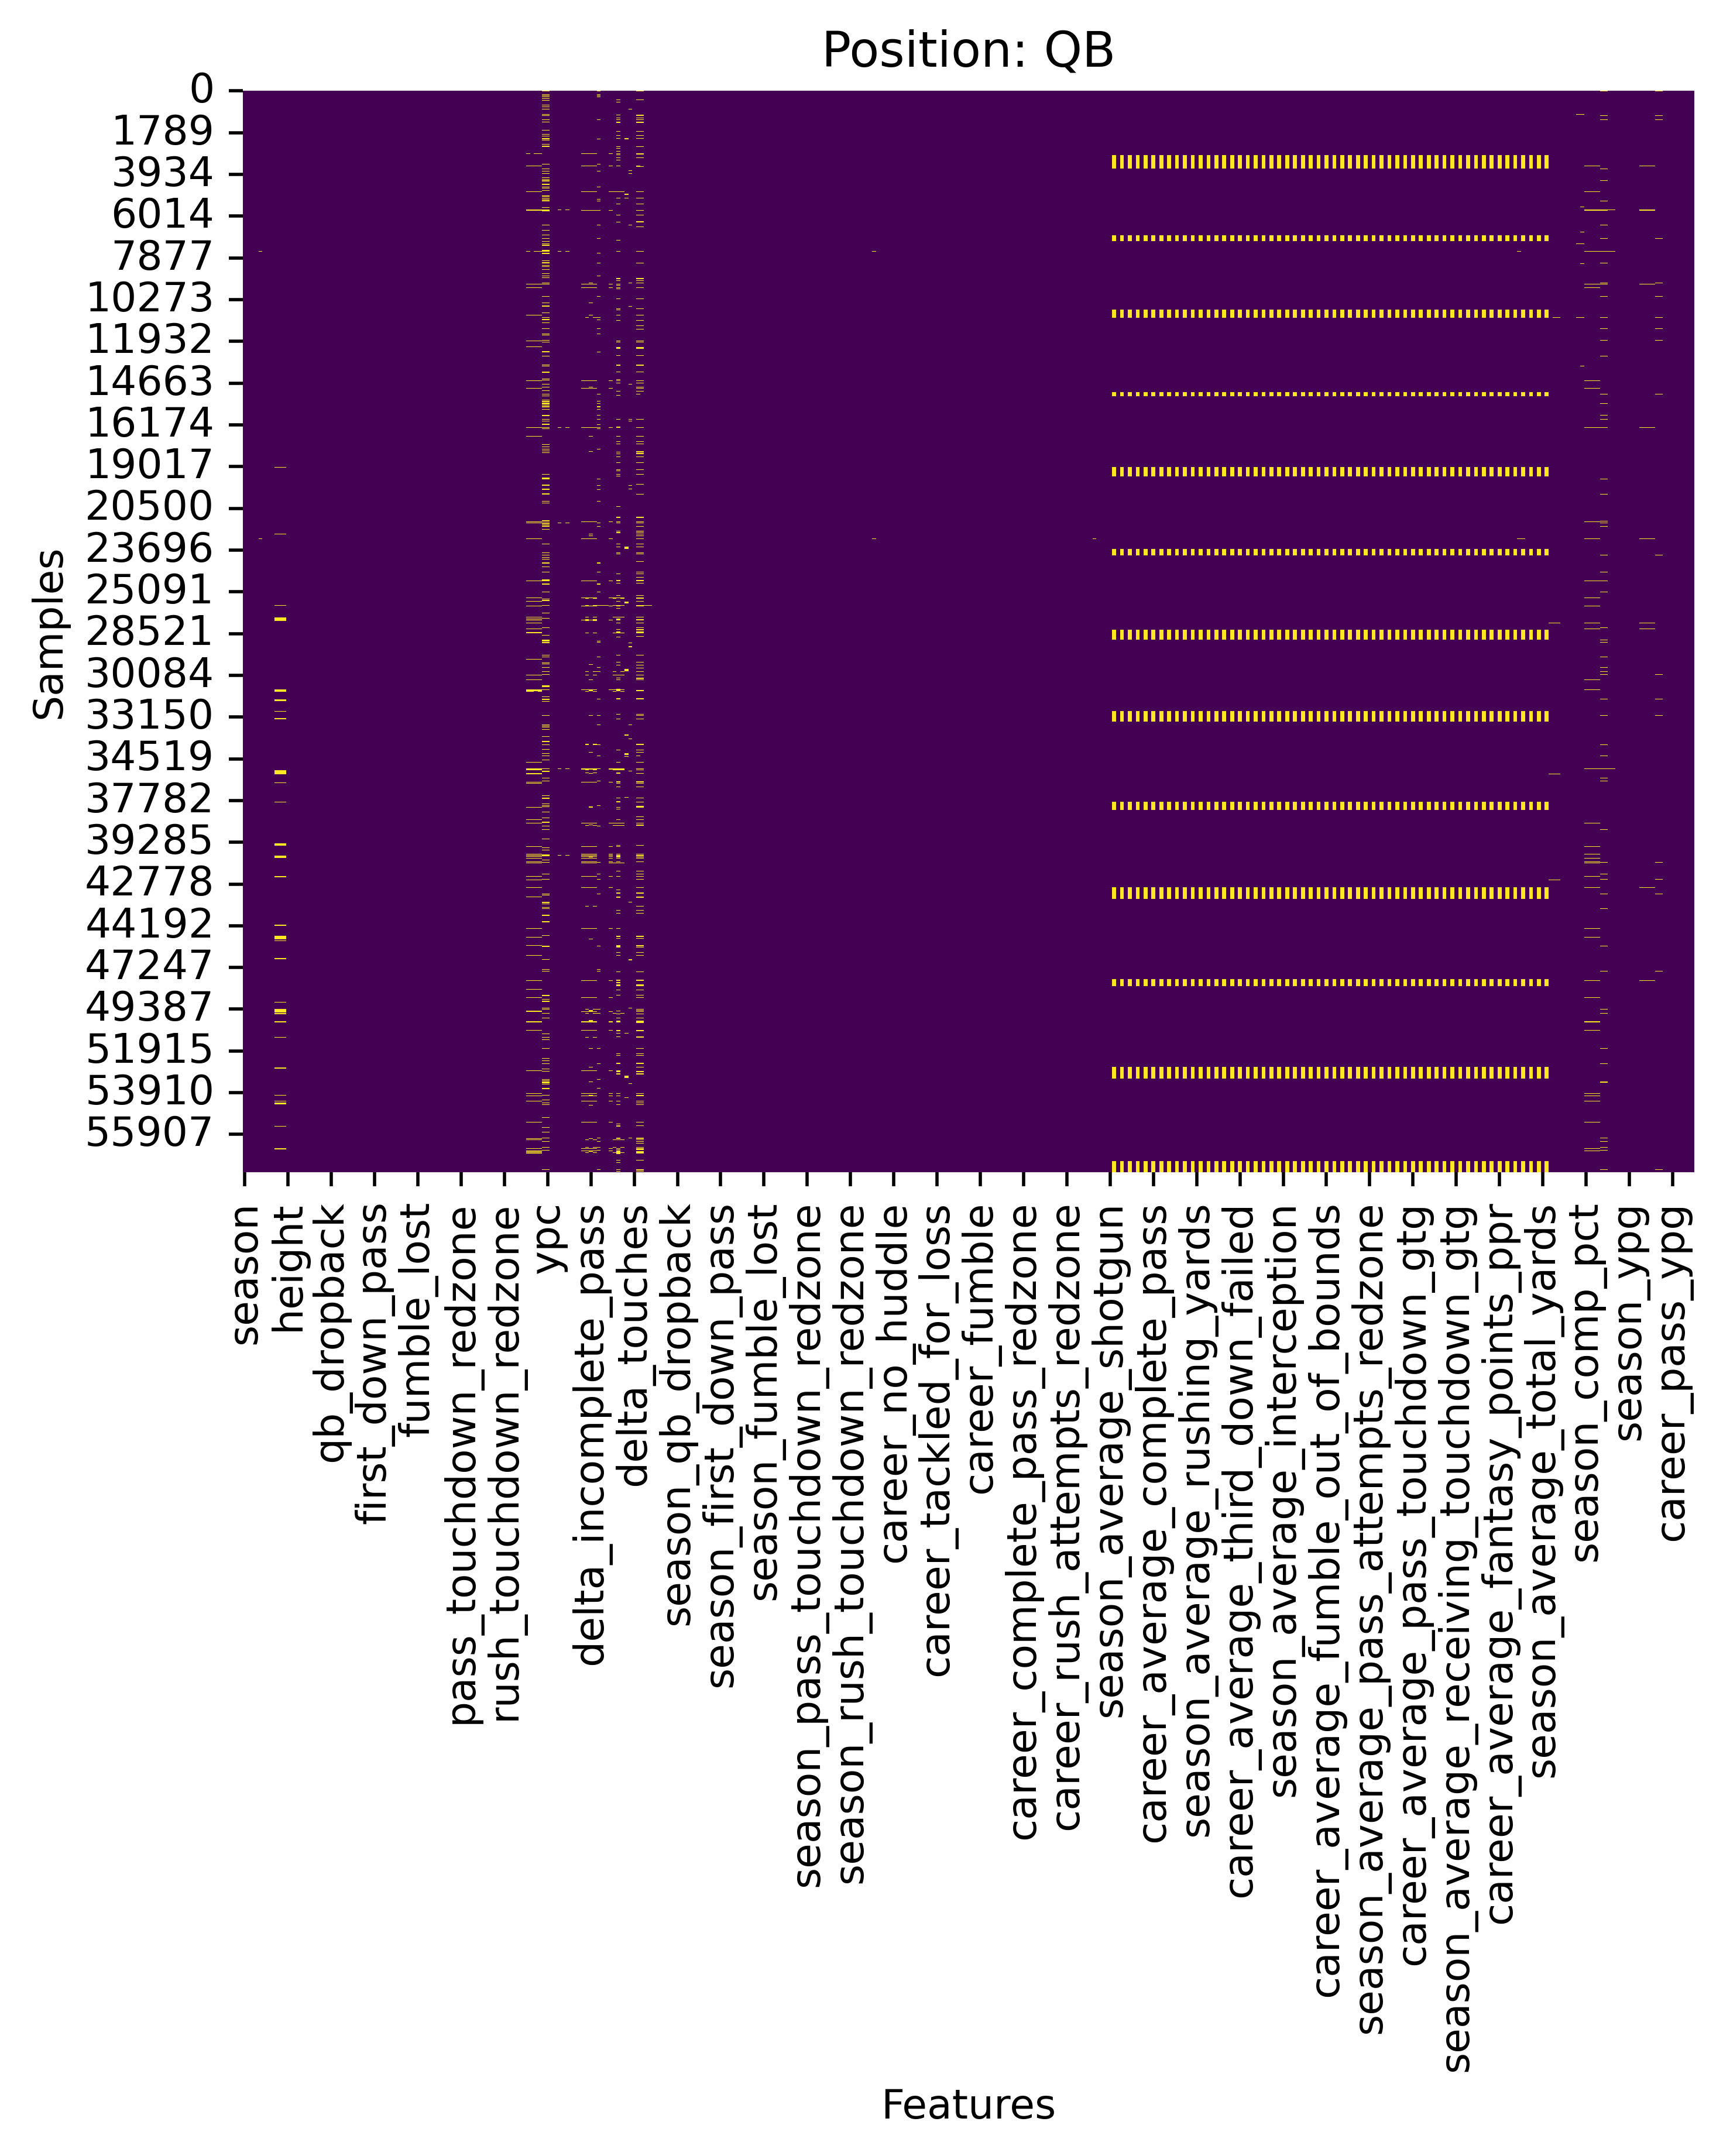

Dropped features for position RB due to missing values: 
adot
comp_pct
int_pct
pass_td_pct
ypa
rec_td_pct
yptarget
ayptarget
ypr
delta_pass_attempts
delta_complete_pass
delta_incomplete_pass
delta_passing_yards
delta_rush_touchdown
delta_rush_attempts_redzone
delta_rush_touchdown_redzone
delta_rush_attempts_gtg
delta_rush_touchdown_gtg
delta_passer_rating
delta_comp_pct
delta_int_pct
delta_pass_td_pct
delta_ypa
delta_rush_td_pct
delta_total_tds
delta_td_pct
career_average_shotgun
career_average_no_huddle
career_average_qb_dropback
career_average_qb_scramble
career_average_pass_attempts
career_average_complete_pass
career_average_incomplete_pass
career_average_passing_yards
career_average_receiving_yards
career_average_yards_after_catch
career_average_rush_attempts
career_average_rushing_yards
career_average_tackled_for_loss
career_average_first_down_pass
career_average_first_down_rush
career_average_third_down_converted
career_average_third_down_failed
career_average_fourth_down_conver

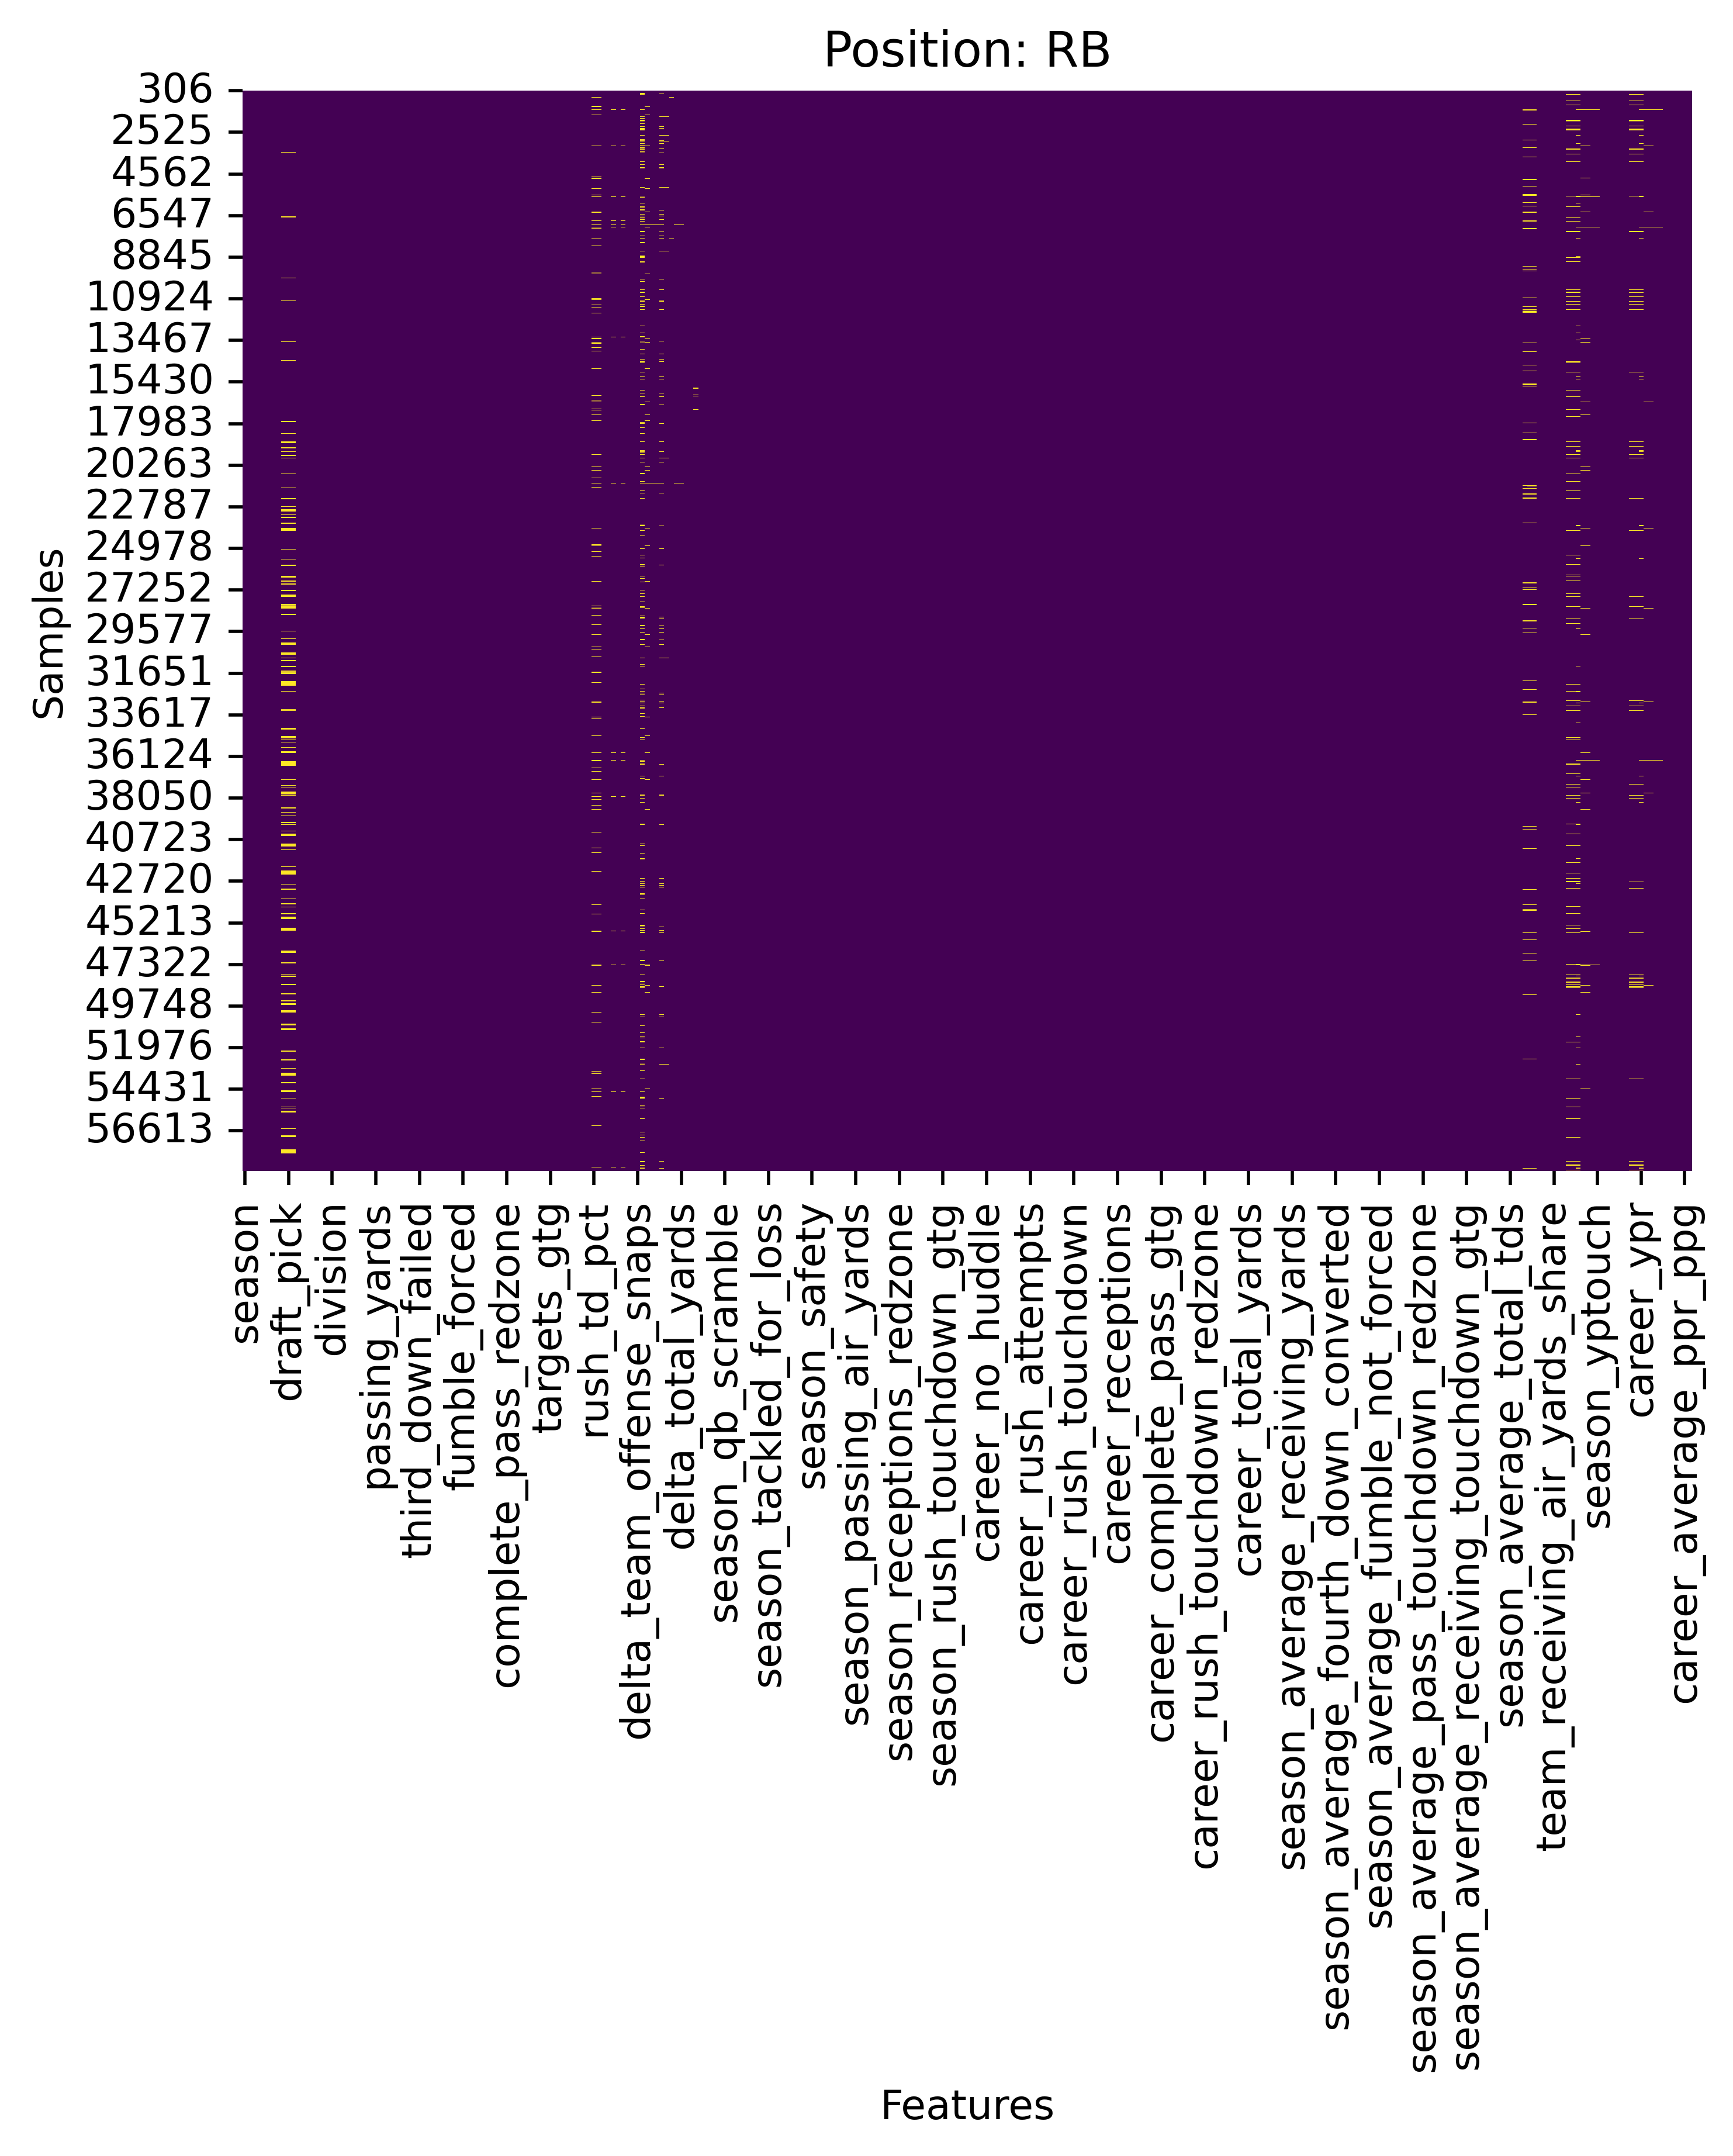

Dropped features for position WR due to missing values: 
comp_pct
int_pct
pass_td_pct
ypa
rush_td_pct
ypc
delta_pass_attempts
delta_complete_pass
delta_incomplete_pass
delta_passing_yards
delta_rush_attempts
delta_rush_touchdown
delta_rush_attempts_redzone
delta_rush_touchdown_redzone
delta_rush_attempts_gtg
delta_rush_touchdown_gtg
delta_passer_rating
delta_comp_pct
delta_int_pct
delta_pass_td_pct
delta_ypa
delta_rush_td_pct
delta_total_tds
delta_td_pct
career_average_shotgun
career_average_no_huddle
career_average_qb_dropback
career_average_qb_scramble
career_average_pass_attempts
career_average_complete_pass
career_average_incomplete_pass
career_average_passing_yards
career_average_receiving_yards
career_average_yards_after_catch
career_average_rush_attempts
career_average_rushing_yards
career_average_tackled_for_loss
career_average_first_down_pass
career_average_first_down_rush
career_average_third_down_converted
career_average_third_down_failed
career_average_fourth_down_converted

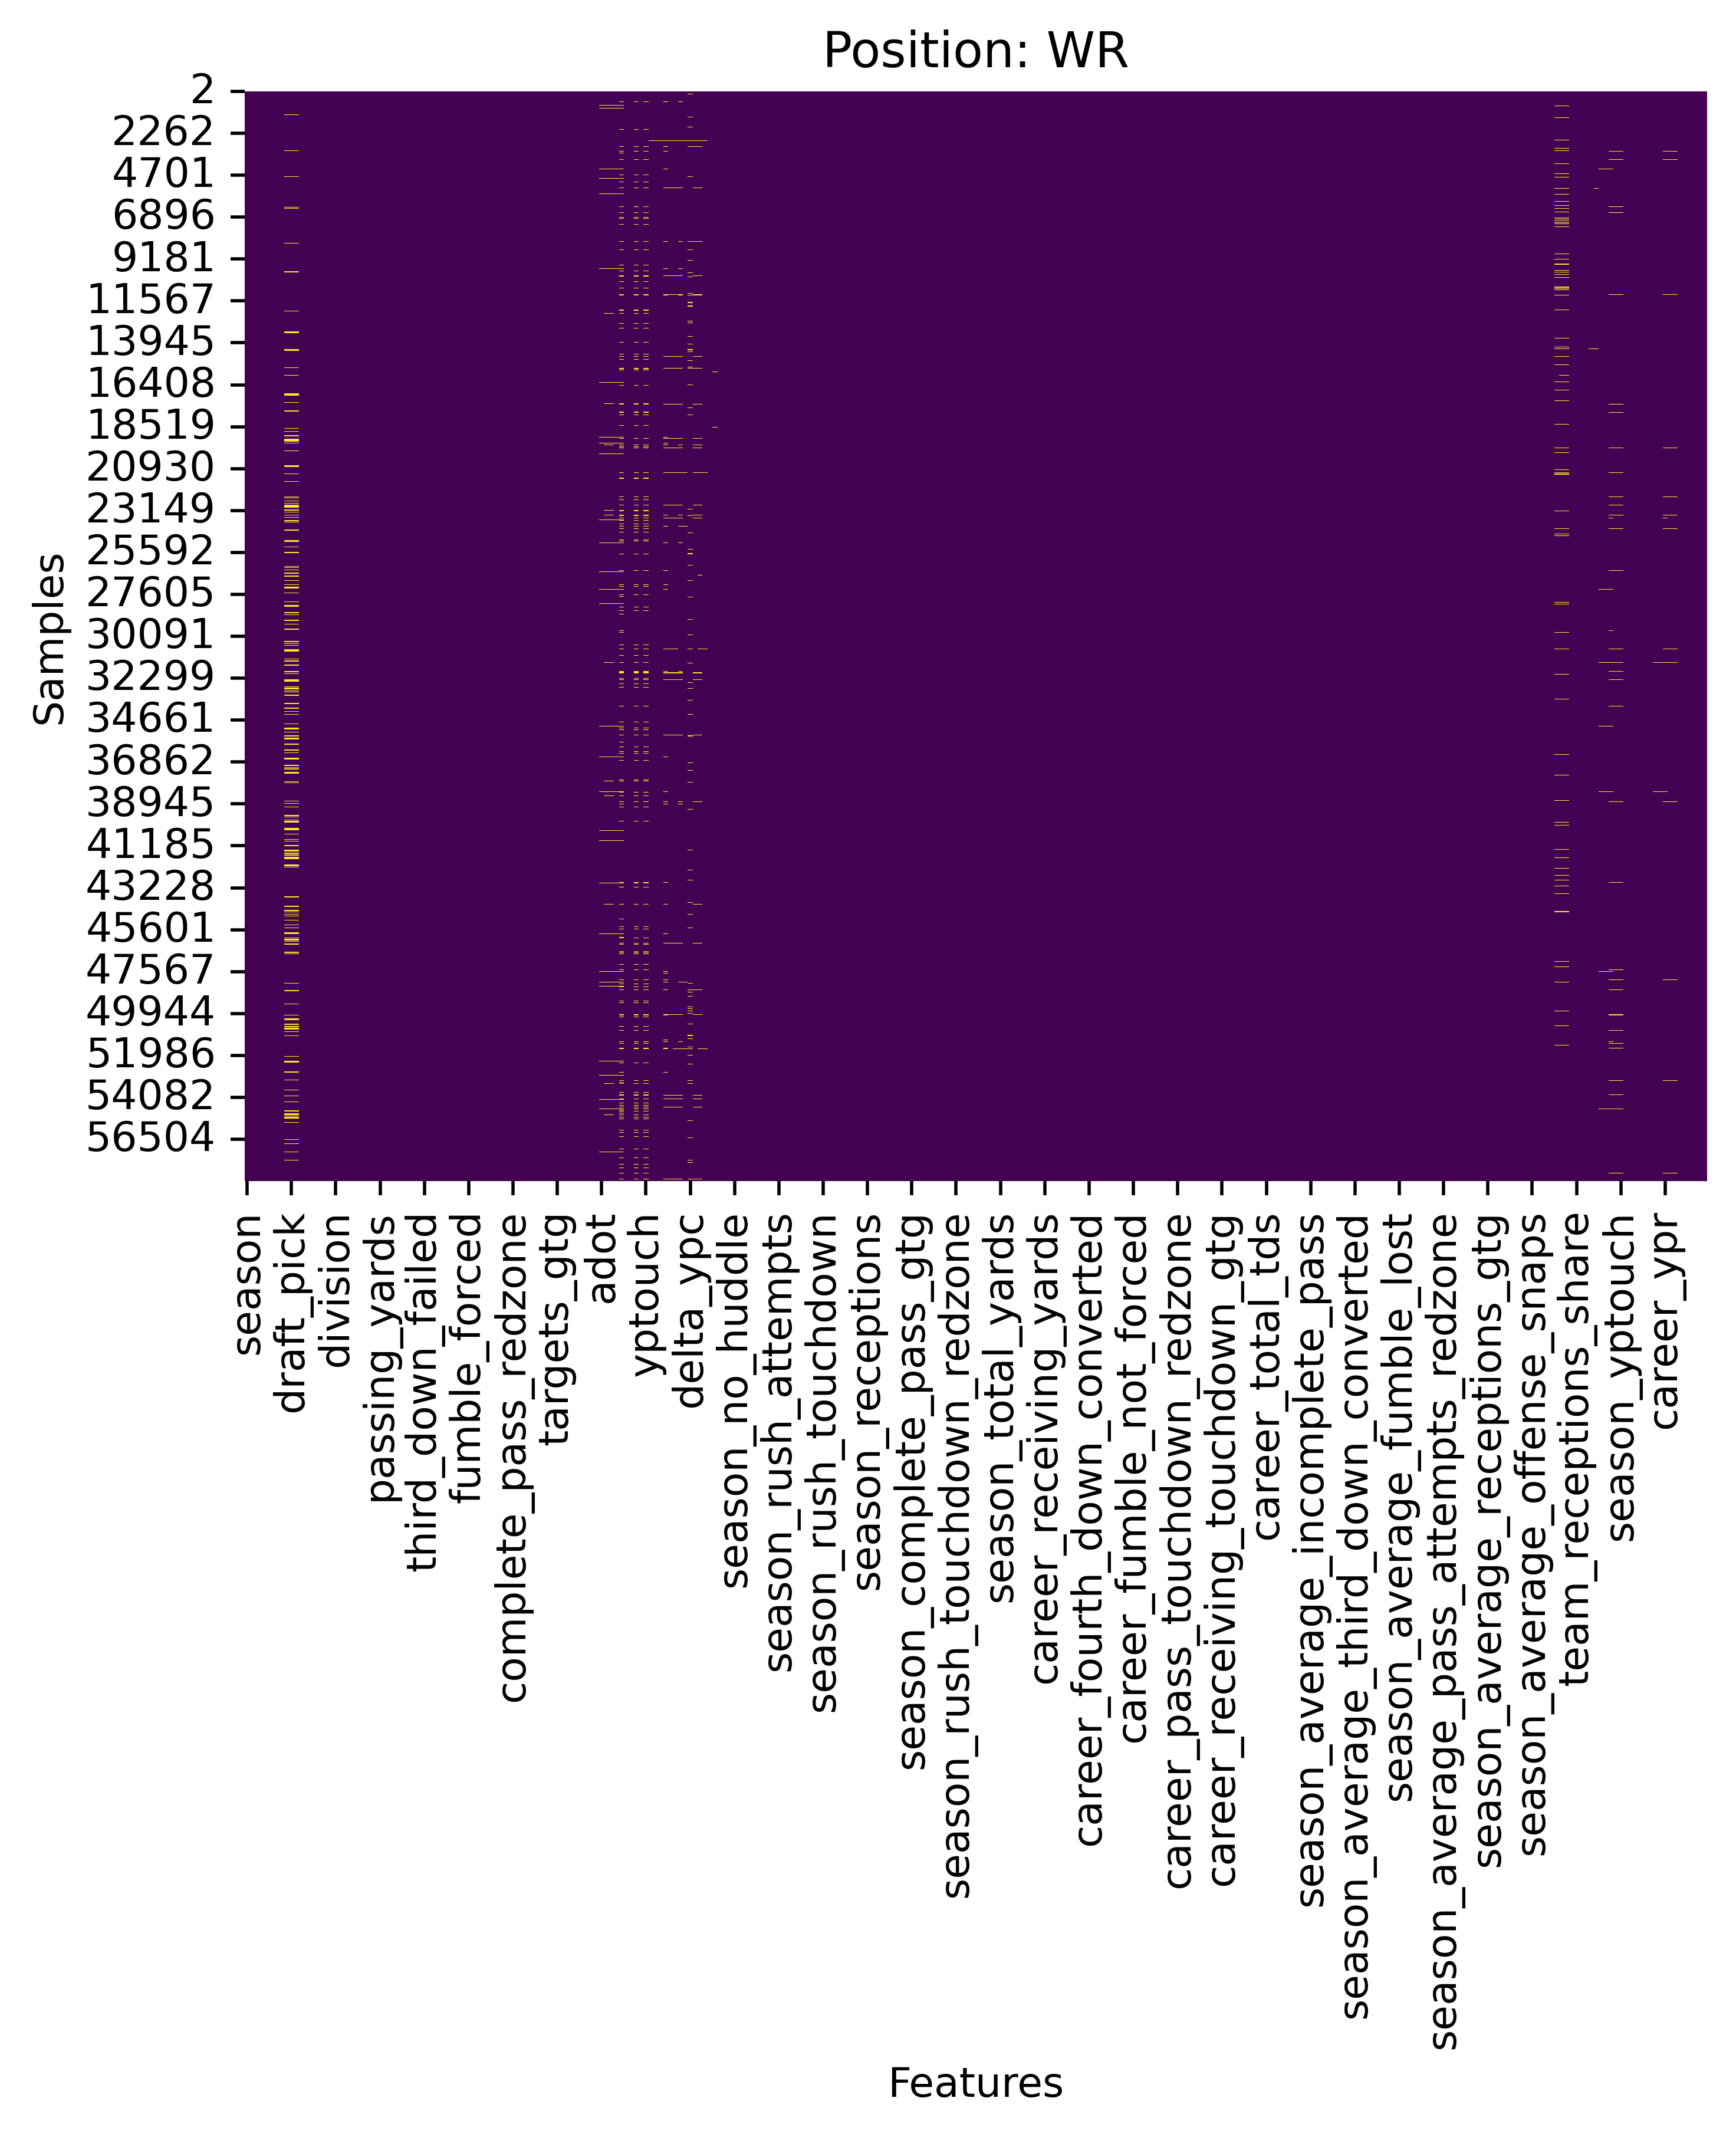

Dropped features for position TE due to missing values: 
comp_pct
int_pct
pass_td_pct
ypa
rush_td_pct
ypc
delta_pass_attempts
delta_complete_pass
delta_incomplete_pass
delta_passing_yards
delta_rush_attempts
delta_rush_touchdown
delta_rush_attempts_redzone
delta_rush_touchdown_redzone
delta_rush_attempts_gtg
delta_rush_touchdown_gtg
delta_passer_rating
delta_comp_pct
delta_int_pct
delta_pass_td_pct
delta_ypa
delta_rush_td_pct
delta_total_tds
delta_td_pct
team_pass_touchdown_share
team_receiving_touchdown_share
team_rush_touchdown_share
season_comp_pct
season_int_pct
season_pass_touchdown_pct
season_ypa
season_rush_td_pct
season_ypc
career_comp_pct
career_int_pct
career_pass_touchdown_pct
career_ypa
career_rush_td_pct
career_ypc
Position TE Filtered DataFrame Features:  ['season', 'week', 'offense_snaps', 'offense_pct', 'team_offense_snaps', 'player_id', 'birth_year', 'draft_year', 'draft_round', 'draft_pick', 'draft_ovr', 'height', 'weight', 'college', 'season_type', 'player_name', 'de

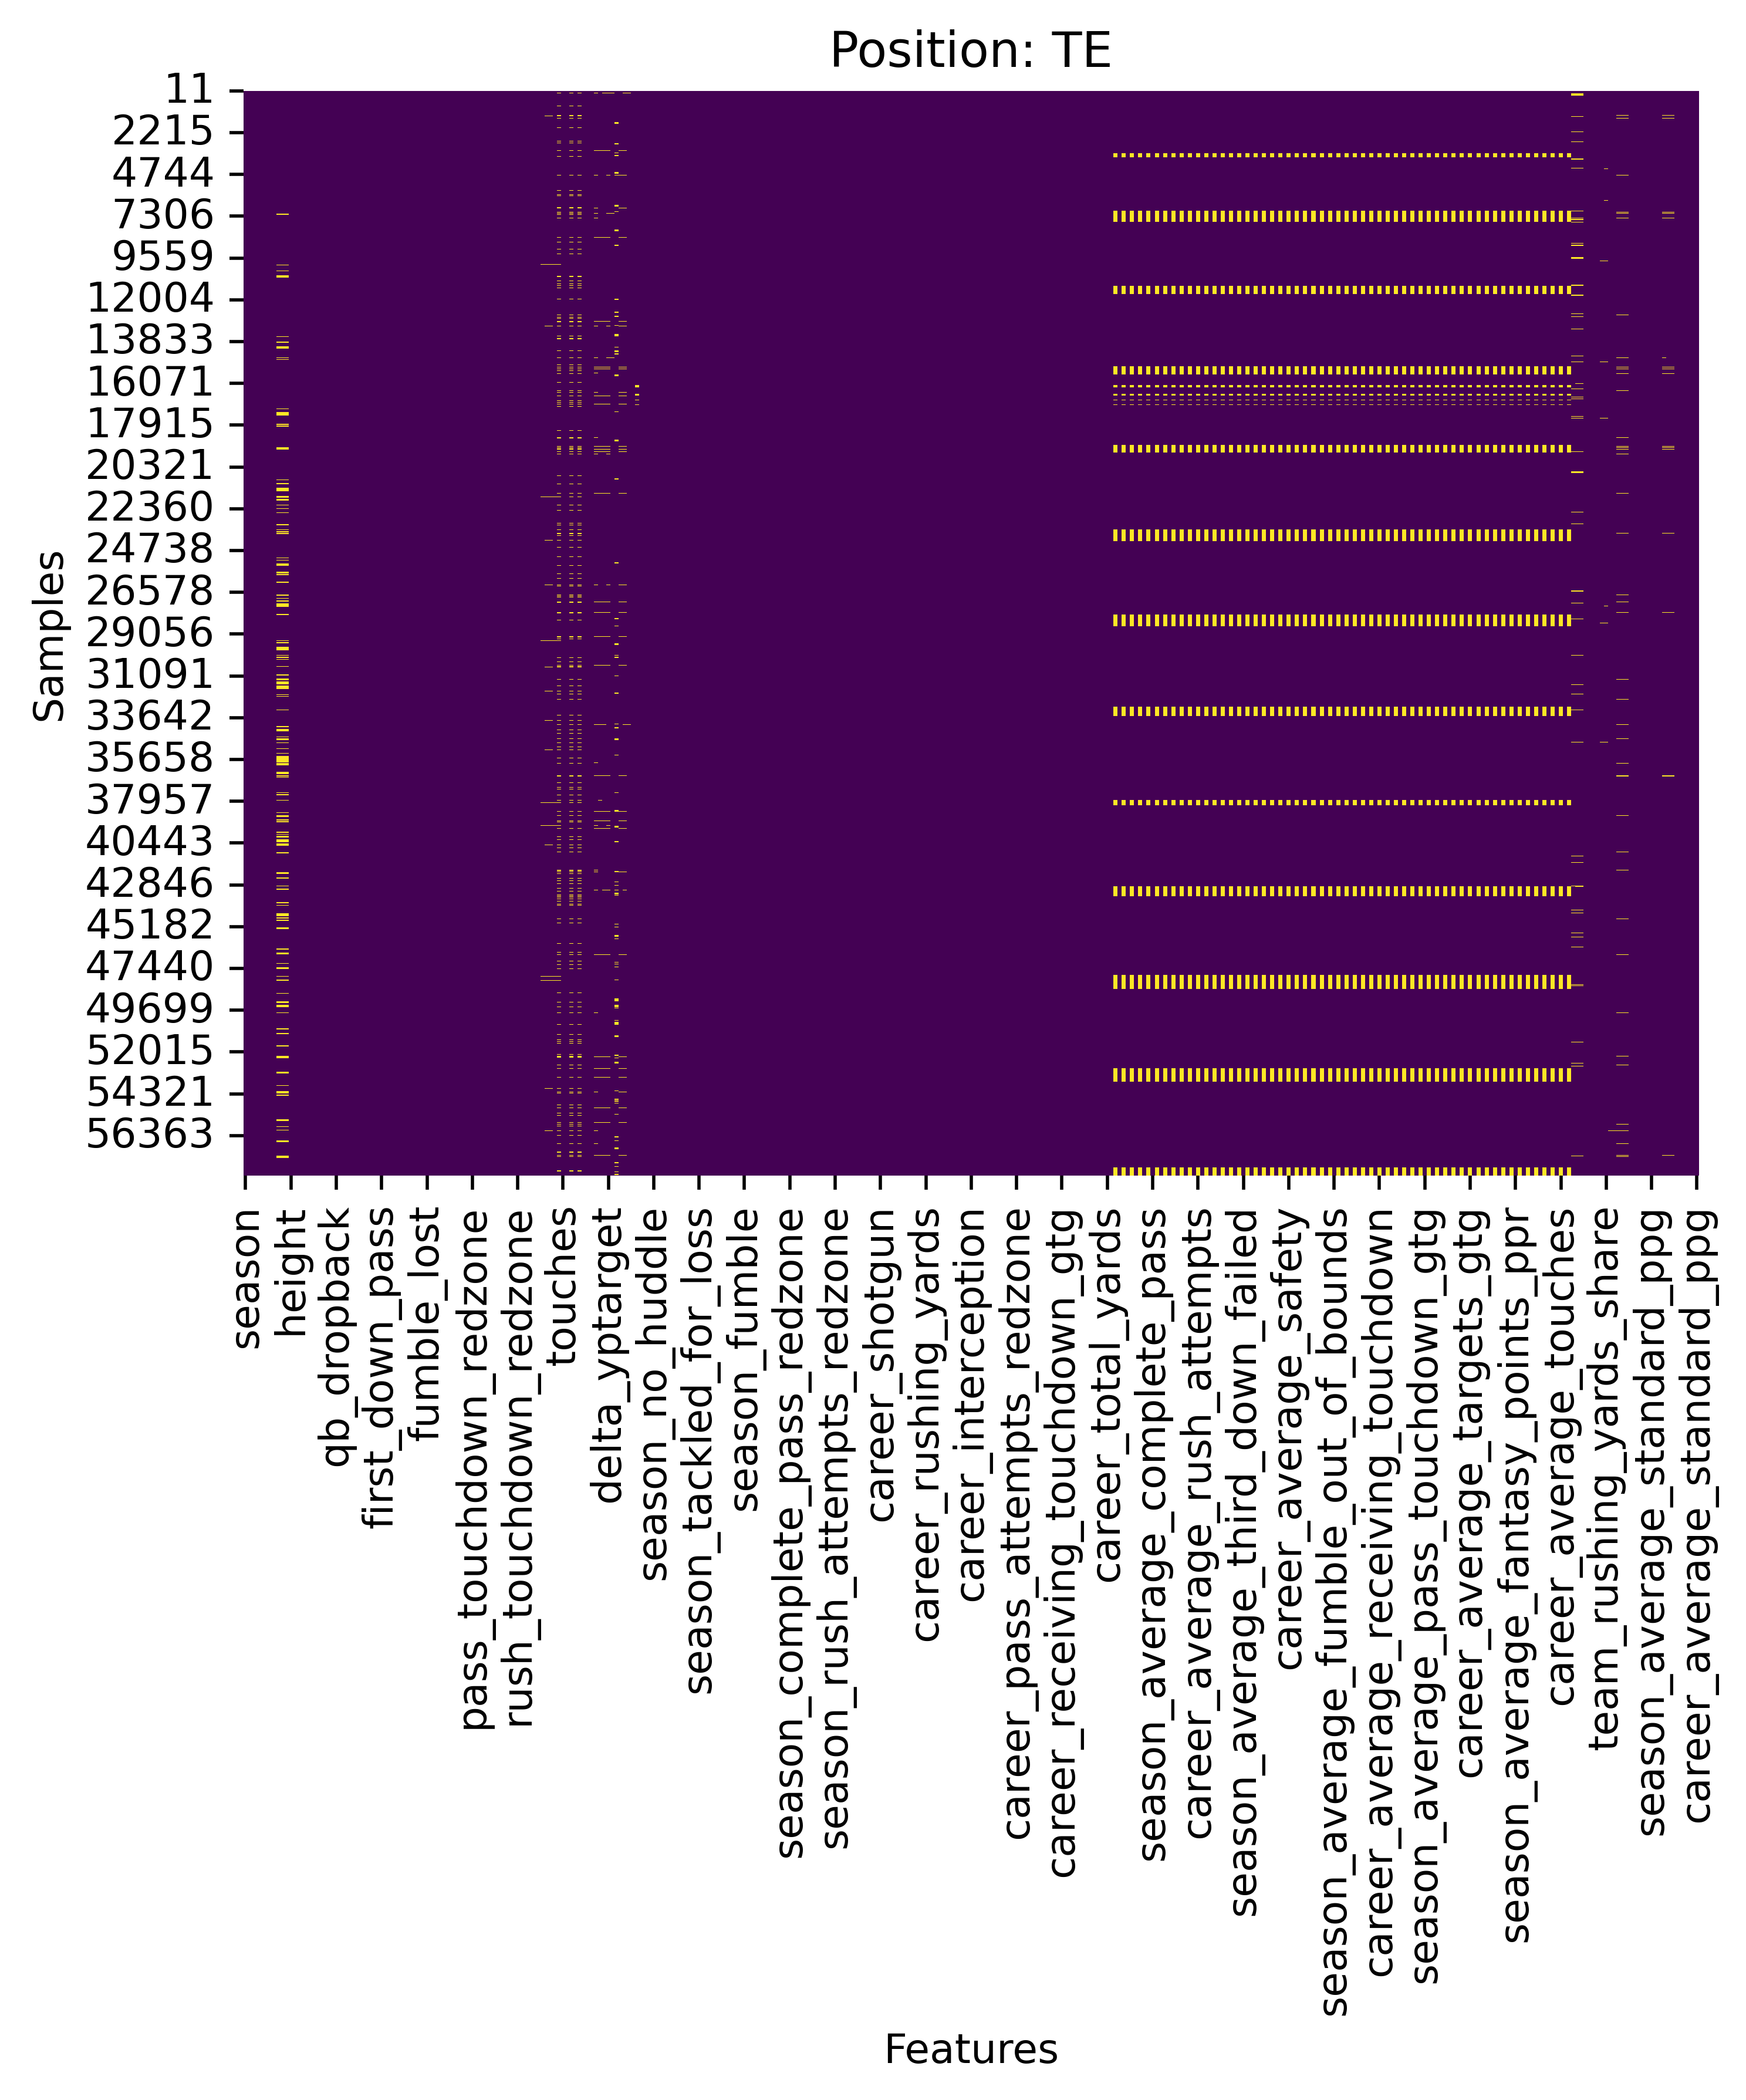

In [ ]:
# The code below creates dataframes filtered by position and drops features with missing values and plots the heat map for each position
# We only want QB, RB, WR, TE
positions = ['QB', 'RB', 'WR', 'TE']
position_filtered_dfs = {}
for position in positions:
	position_df = raw_df[raw_df['position'] == position]
	missing_fraction = position_df.isnull().mean()
	features_to_drop = missing_fraction[missing_fraction > missing_threshold].index
	position_filtered_df = position_df.drop(columns=features_to_drop)
	position_filtered_dfs[position] = position_filtered_df
	print(f"Dropped features for position {position} due to missing values: ")
	for line in features_to_drop.tolist():
		print(f"{line}")
	# Print the heatmap of the position filtered dataframe numerical features
	position_features = [col for col in position_filtered_df.columns if not col == 'position']
	print(f"Position {position} Filtered DataFrame Features: ", position_features)
	# plt.figure(dpi=500)
	# sns.heatmap(position_filtered_df[position_features].isnull() , cbar=False , cmap='viridis')
	# plt.title(f'Position: {position}')
	# plt.ylabel('Samples')
	# plt.xlabel('Features')
	# plt.show()

In [55]:
# Below is the code implementation of a model that can predict fantasy points based on player stats
qb_df = position_filtered_dfs['QB']
rb_df = position_filtered_dfs['RB']
wr_df = position_filtered_dfs['WR']
te_df = position_filtered_dfs['TE']
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For the places where there are missing values, we need to fill htem in with the average of that column
for position, df in position_filtered_dfs.items():
	df_copy = df.copy()
	numeric_cols = [df.select_dtypes(include=['number']).columns]
	for col in numeric_cols:
		mean_value = df[col].mean()
		df[col] = df[col].fillna(mean_value)
	position_filtered_dfs[position] = df_copy

# # print how many samples are in each column of a position dataframe
# for position, df in position_filtered_dfs.items():
# 	print(f"Position: {position}")
# 	print(df.count())
# 	print("\n")
	
def train_and_evaluate_model(position_df, position_name):
	features = position_df.drop(columns=['fantasy_points_ppr', 'position'])
	target = position_df['fantasy_points_ppr']
	real_val_features = features.select_dtypes(include=['number'])
	
	X_train, X_test, y_train, y_test = train_test_split(real_val_features, target, test_size=0.2, random_state=67)
	
	model = RandomForestRegressor(n_estimators=100, random_state=67)
	model.fit(X_train, y_train)
	
	y_pred = model.predict(X_test)
	
	mse = mean_squared_error(y_test, y_pred)
	r2 = r2_score(y_test, y_pred)
	
	print(f"Position: {position_name}")
	print(f"Mean Squared Error: {mse}")
	print(f"R^2 Score: {r2}\n")

train_and_evaluate_model(qb_df, 'QB')
# train_and_evaluate_model(rb_df, 'RB')
# train_and_evaluate_model(wr_df, 'WR')
# train_and_evaluate_model(te_df, 'TE')

Position: QB
Mean Squared Error: 0.0941404830247713
R^2 Score: 0.9992309965758489

